Settings

In [ ]:
from ema_forecast_control.utils import path_utils, model_catalogue

SAVE = False

project_name = f'v3_MRT3_every_day_best_latest_all'

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']

models = model_catalogue.ModelCatalogue(project_name)
test_data_dir = path_utils.join_base_path('data/AI4U_sample3')

### PLRNN

Calculate cumulative impulse responses for inputs targeted at single nodes

In [24]:
import sys
sys.path.append('..')
import os
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control.utils.backwards_compatibility import determine_model_class
from ema_forecast_control.utils import network_utils
from ema_forecast_control.plrnn.plrnn_model import PLRNN

T = 7

errors_loading_model = 0

plrnn_out_centrality = []
plrnn_abs_out_centrality = []
plrnn_cir = []
plrnn_input_selectivity = []

for p, df in path_utils.zip_participants_data(test_data_dir):
    model_dir = models.get_best_latest_model_dir(p, timestep=1000)
    if model_dir is None:
        continue
    args = path_utils.load_args(model_dir)
    if determine_model_class(args) != PLRNN:
        raise ValueError('Model is not PLRNN')
    model = PLRNN()
    model.init_from_model_path(model_dir)
    try:
        Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
    except:
        errors_loading_model += 1
        continue
    x = tc.tensor(df[labels].to_numpy()).float()
    network = network_utils.get_network_matrix(model, x, Gamma=Gamma).nanmean(0)
    model_out_centrality = network_utils.weighted_degree_centrality(network, mode='out', absolute=False)
    model_abs_out_centrality = network_utils.weighted_degree_centrality(network, mode='out', absolute=True)
    perturb_nodes = tc.arange(len(model_out_centrality))
    C = model.get_parameters()['C']
    B = model.get_observation_model()
    
    model_cir = []
    model_input_selectivity = []
    x0 = tc.cat((tc.eye(x.shape[1]).float(), tc.zeros(x.shape[1]).float().unsqueeze(0)), 0)
    for i, item in enumerate(perturb_nodes):
        perturbation = network_utils.target_input_on_node(B, C, item)
        subject_input_selectivity = network_utils.impulse_selectivity_score(B, C, perturbation, item).detach()
        subject_cir = network_utils.impulse_response(model, perturbation, T, cumulative=True, relative=True, x0=x0, 
                                                            Gamma=Gamma, B=B).mean(axis=0)     # mean over initial conditions
        model_cir.append(subject_cir)
        model_input_selectivity.append(subject_input_selectivity)
    model_cir = tc.stack(model_cir, dim=0)
    plrnn_cir.append(model_cir)
    model_input_selectivity = tc.stack(model_input_selectivity, dim=0)
    plrnn_input_selectivity.append(model_input_selectivity)
    plrnn_out_centrality.append(model_out_centrality)
    plrnn_abs_out_centrality.append(model_abs_out_centrality)

plrnn_cir = tc.stack(plrnn_cir, dim=0)
plrnn_input_selectivity = tc.stack(plrnn_input_selectivity, dim=0)
plrnn_out_centrality = tc.stack(plrnn_out_centrality, dim=0)
plrnn_abs_out_centrality = tc.stack(plrnn_abs_out_centrality, dim=0)

if errors_loading_model > 0:
    print(f'Errors loading model: {errors_loading_model}')
### dims of plrnn_cir: (subject, perturb_node, feature)
### dims of plrnn_out_centrality: (subject, perturb_node)

Plot out centrality of nodes against cumulative impulse reponse

In [18]:
plrnn_out_centrality.shape

torch.Size([59, 15])

Low vs. high rank nodes t-test: t(58)=-4.882797861824601, p=8.573716556369162e-06
Correlation between out centrality rank and rCIR:
rank r=0.789, p=0.000


C:\Users\janik.fechtelpeter\AppData\Local\Temp\ipykernel_22100\2632454865.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes2[1].legend()


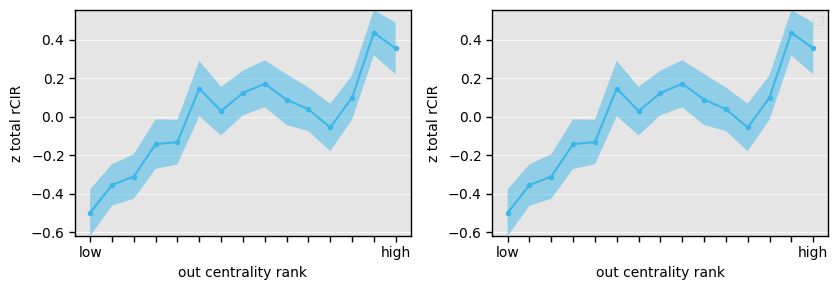

In [25]:
from scipy import stats
import math
from ema_forecast_control.plotting.plotting_styles import PaperStyle

take_absolute_cir = False
standardize_cir = True
standardize_centrality = True
cir = plrnn_cir.clone()
out_centrality = plrnn_out_centrality.clone()

with PaperStyle():
    fig2, axes2 = plt.subplots(1, 2, figsize=(8.5, 3), sharey=False)
    valid_map = ~cir.mean(2).isnan().any(1)
    # standardize out centrality over nodes
    if standardize_centrality:
        z_out_centrality = (out_centrality - out_centrality.mean(1, keepdim=True)) / out_centrality.std(1, keepdim=True)
        label_out_centrality = 'z out centrality'
    else:
        z_out_centrality = out_centrality
        label_out_centrality = 'out centrality'
    z_out_centrality = z_out_centrality[valid_map]
    # standardize cir over perturb_nodes
    if take_absolute_cir:
        cir_mean = tc.abs(cir).mean(2)[valid_map]
        label_cir = 'total abs rCIR'
    else:
        cir_mean = cir.mean(2)[valid_map]
        label_cir = 'total rCIR'
    if standardize_cir:
        z_total_cir = (cir_mean - cir_mean.mean(1, keepdim=True)) / cir_mean.std(1, keepdim=True)
        label_cir = 'z ' + label_cir
    else:
        z_total_cir = cir_mean
    pearsonr = stats.pearsonr(z_out_centrality.flatten(), z_total_cir.flatten())
    r, p = pearsonr.correlation, pearsonr.pvalue

    ordered_cir_mean = z_total_cir.take_along_dim(z_out_centrality.argsort(), dim=1)
    ordered_cir_mean_mean = ordered_cir_mean.mean(0)
    ordered_cir_mean_sem = ordered_cir_mean.std(0) / math.sqrt(ordered_cir_mean.shape[0])
    rankcorr = stats.spearmanr(range(ordered_cir_mean.shape[1]), ordered_cir_mean_mean)
    r, p = rankcorr.correlation, rankcorr.pvalue
    axes2[0].plot(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean, linestyle='-', marker='.')
    axes2[0].fill_between(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean - ordered_cir_mean_sem, ordered_cir_mean_mean + ordered_cir_mean_sem, alpha=0.5)
    axes2[0].set(xlabel='out centrality rank', ylabel=label_cir, title=f'')
    axes2[0].set_xticks(tc.arange(ordered_cir_mean.shape[1])+1, labels=['low']+['']*(ordered_cir_mean.shape[1]-2)+['high'])
    axes2[1].plot(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean, linestyle='-', marker='.', label=f'')
    axes2[1].fill_between(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean - ordered_cir_mean_sem, ordered_cir_mean_mean + ordered_cir_mean_sem, alpha=0.5)
    axes2[1].set(xlabel='out centrality rank', ylabel=label_cir)
    axes2[1].set_xticks(tc.arange(ordered_cir_mean.shape[1])+1, labels=['low']+['']*(ordered_cir_mean.shape[1]-2)+['high'])
    axes2[1].legend()
    fig2.tight_layout()

    # Test highest vs lowest rank node rCIRs
    high_rank_nodes = ordered_cir_mean[:, 0]
    low_rank_nodes = ordered_cir_mean[:, -1]
    rank_nodes_test = stats.ttest_rel(high_rank_nodes, low_rank_nodes)
    print(f'Low vs. high rank nodes t-test: t({rank_nodes_test.df})={rank_nodes_test.statistic}, p={rank_nodes_test.pvalue}')

    print('Correlation between out centrality rank and rCIR:')
    print(f'rank r={r:.3f}, p={p:.3f}')
    if SAVE:
        fig2.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_cir_vs_out_centrality_rank.svg')
    plt.show()

Just rCIR

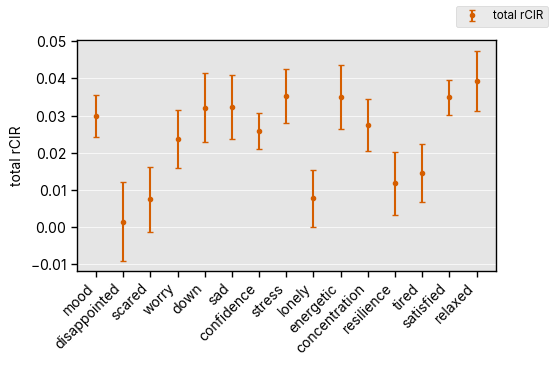

In [14]:
from scipy import stats
import math
from plotting_utils import adjust_ylim

take_absolute_cir = False
standardize_cir = False
cir = plrnn_cir.copy()

cir = tc.concat(cir, dim=0)

color_cycle = colors.color_cycle
with PaperStyle():
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    valid_map = ~cir.mean(2).isnan().any(1)
    if take_absolute_cir:
        cir_mean = tc.abs(cir).mean(2)[valid_map]
        label_cir = 'total abs rCIR'
    else:
        cir_mean = cir.mean(2)[valid_map]
        label_cir = 'total rCIR'
    if standardize_cir:
        z_total_cir = (cir_mean - cir_mean.mean(1, keepdim=True)) / cir_mean.std(1, keepdim=True)
        label_cir = 'z ' + label_cir
    else:
        z_total_cir = cir_mean
    cir_participant_mean = z_total_cir.mean(0)
    cir_participant_sem = z_total_cir.std(0) / math.sqrt(z_total_cir.shape[0])
    ax.set(ylabel=label_cir)    
    ax.errorbar(tc.arange(len(PRINT_LABELS)), cir_participant_mean, yerr=cir_participant_sem, linestyle='', marker='.', color=color_cycle[5], label=label_cir)
    ax.set_xticks(tc.arange(len(PRINT_LABELS)), PRINT_LABELS, rotation=45, ha='right')
    adjust_ylim(ax)
    fig.legend()
    if SAVE:
        fig.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_cir.svg')
    plt.show()

Just selectivity

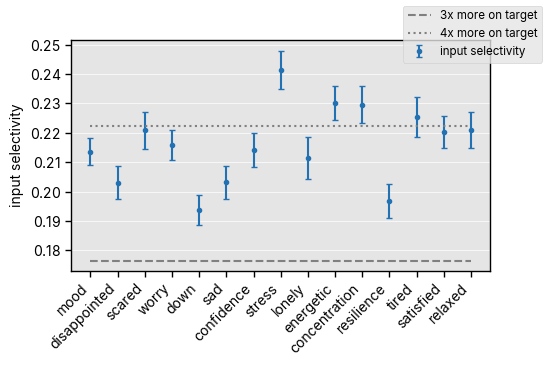

In [15]:
from scipy import stats
import math
from plotting_utils import adjust_ylim

selectivity = plrnn_input_selectivity_new.copy()
selectivity = tc.concat(selectivity, dim=0)

color_cycle = colors.color_cycle
with PaperStyle():
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    selectivity_participant_mean = selectivity.mean(0)
    selectivity_participant_sem = selectivity.std(0) / math.sqrt(selectivity.shape[0])
    triple_selectivity = 3 / (selectivity.shape[1]+2)
    quadruple_selectivity = 4 / (selectivity.shape[1]+3)
    # quintuple_selectivity = 5 / (selectivity.shape[1]+4)
    ax.set(ylabel='input selectivity')    
    ax.errorbar(tc.arange(len(PRINT_LABELS)), selectivity_participant_mean, yerr=selectivity_participant_sem, linestyle='', marker='.', color=color_cycle[4], label='input selectivity')
    x_lim = [0, len(PRINT_LABELS)-1]
    ax.plot(x_lim, [triple_selectivity, triple_selectivity], linestyle='--', color='gray', label='3x more on target')
    ax.plot(x_lim, [quadruple_selectivity, quadruple_selectivity], linestyle=':', color='gray', label='4x more on target')
    # ax.plot(x_lim, [quintuple_selectivity, quintuple_selectivity], linestyle='--', color='blue', label='5x more on target')
    ax.set_xticks(tc.arange(len(PRINT_LABELS)), PRINT_LABELS, rotation=45, ha='right')
    adjust_ylim(ax)
    fig.legend()
    if SAVE:
        fig.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_input_selectivity.svg')
    plt.show()